## Adaptive ElasticNet

[![Slides](https://img.shields.io/badge/🦌-ReHLine-blueviolet)](https://rehline-python.readthedocs.io/en/latest/)

Adaptive ElasticNet solves the following optimization problem:
$$
\min_{\beta \in \mathbb{R}^d} \; C \sum_{i=1}^{n} \text{PLQ}(y_i, \mathbf{x}_i^T \beta) + \ell_1\text{ratio} \sum_{j=1}^{d} \omega_j |\beta_j| + \frac{1}{2}(1 - \ell_1\text{ratio})\|\beta\|_2^2, \quad \text{s.t.} \quad \mathbf{A}\beta + \mathbf{b} \geq \mathbf{0},
$$

where

- $\text{PLQ}(\cdot)$ is a piecewise linear-quadratic loss function (e.g., hinge, quantile, Huber),
- $\mathbf{x}_i \in \mathbb{R}^d$ is a feature vector,
- $y_i$ is the response variable (class label or continuous value),
- $C > 0$ is the regularization strength (larger $C$ = less regularization),
- $\ell_1\text{ratio} \in [0, 1)$ is the mixing parameter: $\ell_1\text{ratio} = 0$ gives Ridge,
- $\omega_j > 0$ is a data-dependent $\ell_1$-penalty weight applied to $\beta_j$,
- $\mathbf{A}\beta + \mathbf{b} \geq \mathbf{0}$ represents optional linear constraints on $\beta$.

In this example, we use squared loss and let $\omega_j = {|\beta^{\text{OLS}}_j|^{-1}}$

In [1]:
## packages
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

from rehline import plqERM_ElasticNet

In [2]:
## data simulation
n, d = 1000, 12
seed = 42
C = 0.001
l1_ratio = 0.5

X, y, beta_true = make_regression(
                n_samples=n,
                n_features=d,
                noise=0.1,
                random_state=seed,
                n_informative=4,
                coef=True
)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=seed
)
scaler = StandardScaler()
X_train_standered = scaler.fit_transform(X_train)
X_test_standered = scaler.transform(X_test)

In [3]:
## fit the OLS solution
ols = LinearRegression(fit_intercept=False)
ols.fit(X_train, y_train)
beta_ols = ols.coef_
omega = 1 / np.abs(beta_ols)

In [4]:
## apply the adaptive LASSO weights
clf_ENAL = plqERM_ElasticNet(
            loss={"name":"MSE"},
            C=C,
            l1_ratio=l1_ratio,
            omega=omega,
            max_iter=30000,
            shrink=seed,
            verbose=1
)
clf_ENAL.fit(X_train, y_train)
beta_ENAL = clf_ENAL.coef_.flatten()

In [5]:
## fit an elastic net model for comparison
clf_EN = plqERM_ElasticNet(
            loss={"name":"MSE"},
            C=C,
            l1_ratio=l1_ratio,
            max_iter=30000,
            shrink=seed,
            verbose=1
)
clf_EN.fit(X_train, y_train)
beta_EN = clf_EN.coef_.flatten()

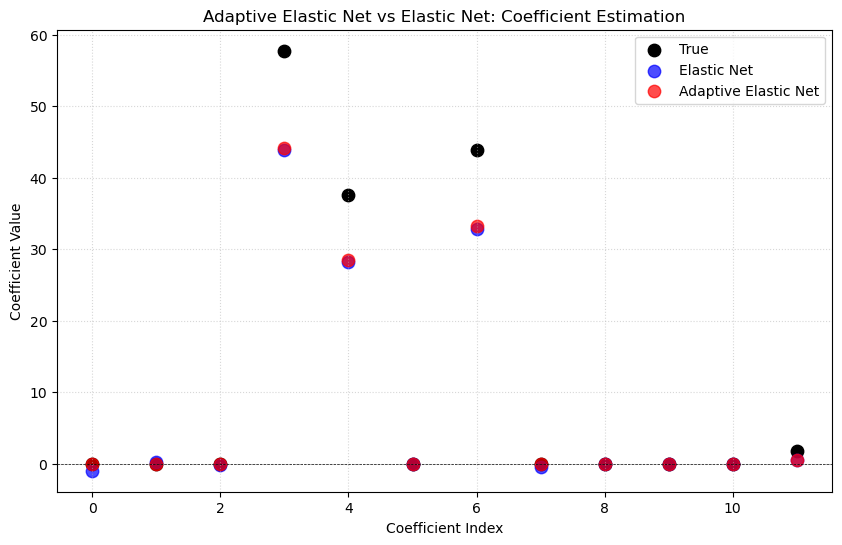

In [6]:
idx = np.arange(len(beta_true))
plt.figure(figsize=(10, 6))

# True Parameters
plt.scatter(idx, beta_true, 
            color='black', label='True', s=80, marker='o')

# Elastic Net Estimates
plt.scatter(idx, beta_EN / scaler.scale_, 
            color='blue', label='Elastic Net', s=80, alpha=0.7)

# Adaptive Elastic Net Estimates
plt.scatter(idx, beta_ENAL / scaler.scale_, 
            color='red', label='Adaptive Elastic Net', s=80, alpha=0.7)

plt.axhline(0, color='k', linestyle='--', linewidth=0.5)
plt.xlabel('Coefficient Index')
plt.ylabel('Coefficient Value')
plt.legend()
plt.title('Adaptive Elastic Net vs Elastic Net: Coefficient Estimation')
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()